In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_column',None)
pd.options.display.float_format = '{:.4f}'.format


## Data Loading & Initial Exploration

In [2]:
dt = pd.read_excel(r'/content/income_est.xlsx')
dt

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,longitude,merchant_code,merchant_id,merchant_state,merchant_suburb,movement,status,transaction_id,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period,annual_salary
0,ACC-1598451071,26,16.25,35.39,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,153.41,NaN,81c48296-73be-44a7-befa-d053f48ce7cd,QLD,Ashmore,debit,authorized,a623070bfead4541a6b0fff8a09e706c,POS,20-30,2018,8,1,1,1,Wednesday,7,52856
1,ACC-1598451071,26,14.19,21.20,0.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,153.41,NaN,830a451c-316e-4a6a-bf25-e37caedca49e,NSW,Sydney,debit,authorized,13270a2a902145da9db4c951e04b51b9,SALES-POS,20-30,2018,8,1,1,13,Wednesday,7,52856
2,ACC-1598451071,26,3.25,17.95,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,153.41,NaN,b4e02c10-0852-4273-b8fd-7b3395e32eb0,QLD,Mermaid Beach,debit,authorized,329adf79878c4cf0aeb4188b4691c266,SALES-POS,20-30,2018,8,1,1,51,Wednesday,7,52856
3,ACC-1598451071,26,14.10,3.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,153.41,NaN,f2ef6270-cf91-409f-a6a2-fbd6735ea500,NSW,Byron Bay,debit,authorized,1c12c9ad77894ef8b507fb091e41e928,POS,20-30,2018,8,1,8,9,Wednesday,7,52856
4,ACC-1598451071,26,10.67,1006.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,153.41,NaN,44abc19c-aa5c-40bd-b1d0-9b2f236189ea,QLD,Bundall,debit,authorized,cd0113426970425a8524e55f4079408f,POS,20-30,2018,8,1,18,19,Wednesday,7,52856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12038,ACC-2153562714,24,3712.56,9707.77,NaN,CUS-423725039,2018-10-24,Linda,F,-31.88,116.00,0.0,NaN,NaN,NaN,credit,posted,fe1b1a6bdd9b43f7985acc4af7b0a101,PAY/SALARY,20-30,2018,10,24,14,0,Wednesday,30,45169
12039,ACC-1217063613,27,4863.62,4863.86,NaN,CUS-1739931018,2018-09-26,Kimberly,F,-37.82,147.61,0.0,NaN,NaN,NaN,credit,posted,8659baa692924427aefbf4077c5a9d67,PAY/SALARY,20-30,2018,9,26,13,0,Wednesday,30,59174
12040,ACC-1217063613,27,4863.62,8905.77,NaN,CUS-1739931018,2018-10-26,Kimberly,F,-37.82,147.61,0.0,NaN,NaN,NaN,credit,posted,e6d8f31d269d4e8388e115719a59dd98,PAY/SALARY,20-30,2018,10,26,13,0,Friday,30,59174
12041,ACC-3100725361,25,6107.23,6111.57,NaN,CUS-2178051368,2018-09-26,Ronald,M,-17.03,145.73,0.0,NaN,NaN,NaN,credit,posted,7eb1fdb7aefb40d1a8ada1d27f556542,PAY/SALARY,20-30,2018,9,26,15,0,Wednesday,30,74305


In [3]:
dt.describe(include='all')

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,longitude,merchant_code,merchant_id,merchant_state,merchant_suburb,movement,status,transaction_id,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period,annual_salary
count,12043,12043.000000,12043.000000,12043.000000,7717.000000,12043,12043,12043,12043,12043.000000,12043.000000,883.0,7717,7717,7717,12043,12043,12043,12043,12043,12043.0,12043.000000,12043.000000,12043.000000,12043.000000,12043,12043.000000,12043.000000
unique,100,NaN,NaN,NaN,NaN,100,91,80,2,NaN,NaN,NaN,5725,8,1609,2,2,12043,6,7,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN
top,ACC-1598451071,NaN,NaN,NaN,NaN,CUS-2487424745,2018-09-28,Michael,M,NaN,NaN,NaN,106e1272-44ab-4dcb-a438-dd98e0071e51,NSW,Melbourne,debit,authorized,56e1a0f55f354624a3c713c37415d216,SALES-POS,20-30,NaN,NaN,NaN,NaN,NaN,Friday,NaN,NaN
freq,578,NaN,NaN,NaN,NaN,578,174,746,6285,NaN,NaN,NaN,14,2169,255,11160,7717,1,3934,5071,NaN,NaN,NaN,NaN,NaN,2073,NaN,NaN
mean,NaN,30.582330,187.933588,14704.195553,0.802644,NaN,NaN,NaN,NaN,-38.164347,143.648563,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,9.011957,15.862908,13.268621,19.009632,NaN,11.470315,68652.099311
std,NaN,10.046343,592.599934,31503.722652,0.398029,NaN,NaN,NaN,NaN,54.622791,16.669352,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.816511,8.899598,5.777284,19.879112,NaN,7.049721,24300.863348
min,NaN,18.000000,0.100000,0.240000,0.000000,NaN,NaN,NaN,NaN,-573.000000,114.620000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,8.000000,1.000000,0.000000,0.000000,NaN,0.000000,29875.000000
25%,NaN,22.000000,16.000000,3158.585000,1.000000,NaN,NaN,NaN,NaN,-37.700000,138.690000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,8.000000,8.000000,9.000000,0.000000,NaN,7.000000,51650.000000
50%,NaN,28.000000,29.000000,6432.010000,1.000000,NaN,NaN,NaN,NaN,-33.890000,145.230000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,9.000000,16.000000,13.000000,13.000000,NaN,14.000000,60494.000000
75%,NaN,38.000000,53.655000,12465.945000,1.000000,NaN,NaN,NaN,NaN,-30.750000,151.220000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,10.000000,24.000000,18.000000,36.000000,NaN,14.000000,81701.000000


In [4]:
dt.isnull().sum()

,0
account,0
age,0
amount,0
balance,0
card_present_flag,4326
customer_id,0
date,0
first_name,0
gender,0
latitude,0


In [5]:
dt.drop(dt[['account','date','customer_id','first_name','transaction_id','merchant_id']],axis=1,inplace=True)

In [6]:
for i in dt.columns:
  if dt[i].dtypes != object:
    dt[i].fillna(dt[i].mean(), inplace=True)
  else:
    dt[i].fillna(dt[i].mode()[0], inplace=True)

/tmp/ipykernel_16695/2580584024.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dt[i].fillna(dt[i].mean(), inplace=True)
/tmp/ipykernel_16695/2580584024.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [7]:
dt.isnull().sum()

,0
age,0
amount,0
balance,0
card_present_flag,0
gender,0
latitude,0
longitude,0
merchant_code,0
merchant_state,0
merchant_suburb,0


## Feature Engineering

In [8]:
dt['balance_to_amount_ratio'] = dt['balance'] / (dt['amount'] + 1)
dt['is_salary_transaction'] = (dt['txn_description'] == 'PAY/SALARY').astype(int)
dt['is_weekend_spender'] = dt['dow'].isin(['Saturday', 'Sunday']).astype(int)
dt['is_debit'] = (dt['movement'] == 'debit').astype(int)
dt['is_business_hours'] = dt['hour'].between(9, 17).astype(int)
dt['age_balance_interaction'] = dt['age'] * dt['balance']
dt['is_card_present'] = dt['card_present_flag'].fillna(0).astype(int)
dt['amount_per_payment_period'] = dt['amount'] / (dt['payment_period'] + 1)
dt['is_authorized_only'] = (dt['status'] == 'authorized').astype(int)

In [10]:
dt.drop(dt[['merchant_suburb']],axis=1, inplace=True)

In [11]:
dt_rf = dt.copy()
dt_knn = dt.copy()

## Model-Specific Preprocessing: Random Forest

In [12]:
dt_rf['gender'] = dt_rf['gender'].map({'F':0, 'M':1})
dt_rf['movement'] = dt_rf['movement'].map({'credit':0, 'debit':1})
dt_rf['status'] = dt_rf['status'].map({'authorized':0, 'posted':1})
dt_rf['txn_description'] = dt_rf['txn_description'].map({'PAY/SALARY':0, 'POS':1,'SALES-POS':2,'PAYMENT':3,'INTER BANK':4,'PHONE BANK':5})

In [120]:
bin_age_map = {
    '<20': 1,
    '20-30': 2,
    '30-40': 3,
    '40-50': 4,
    '50-60': 5,
    '60-70': 6,
    '70>': 7
}

dt['bin_age'] = dt_rf['bin_age'].map(bin_age_map)

In [14]:
le = LabelEncoder()
for i in dt_rf.columns:
  if dt_rf[i].dtypes == object:
    dt_rf[i] = le.fit_transform(dt_rf[i])


## Model-Specific Preprocessing: KNN

### Outlier Treatment

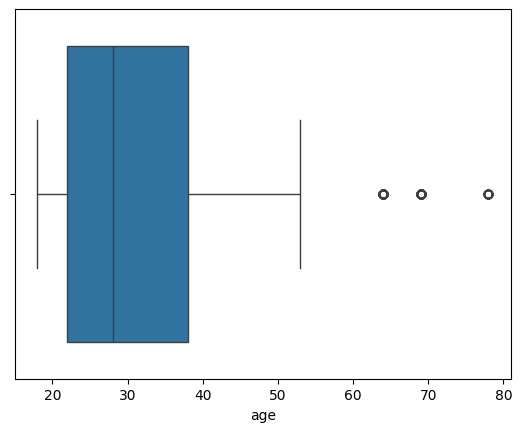

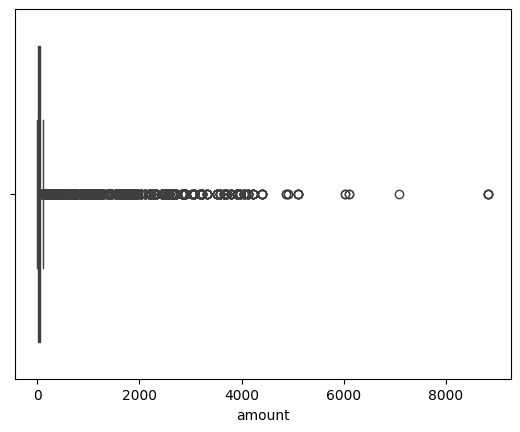

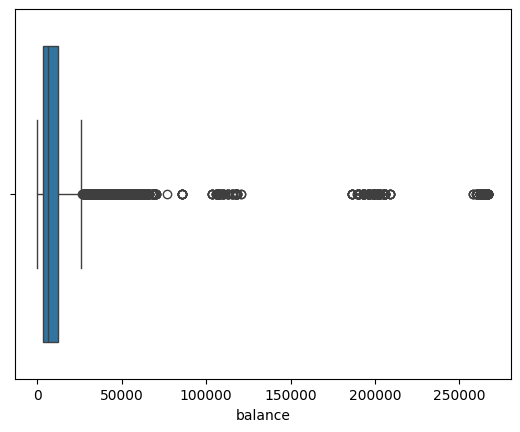

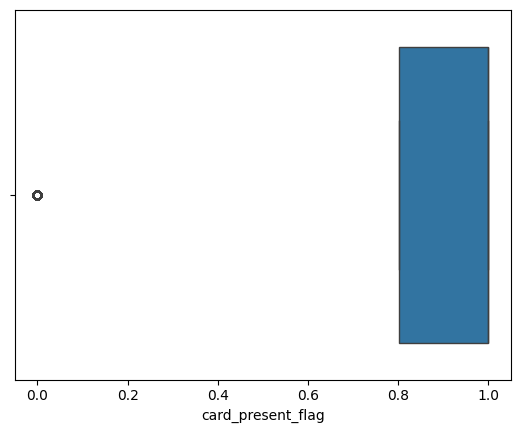

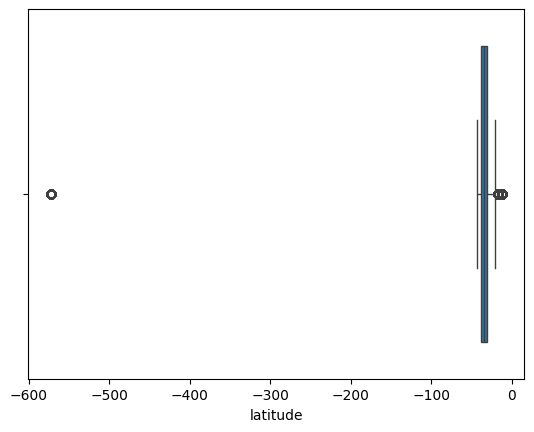

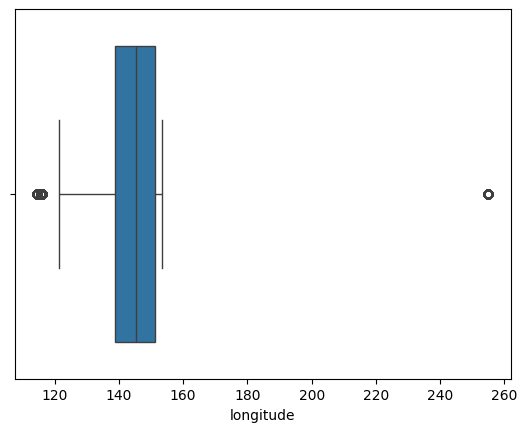

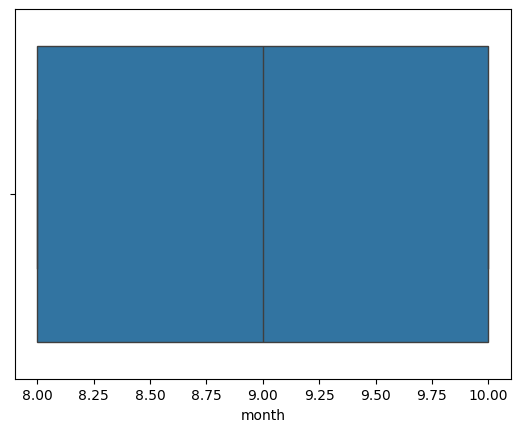

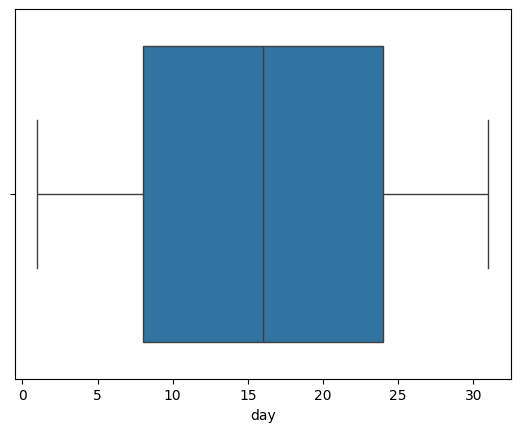

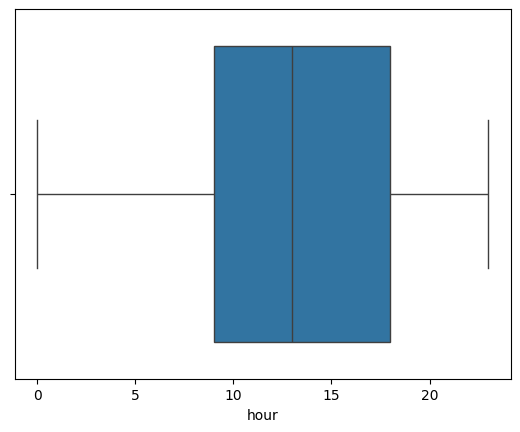

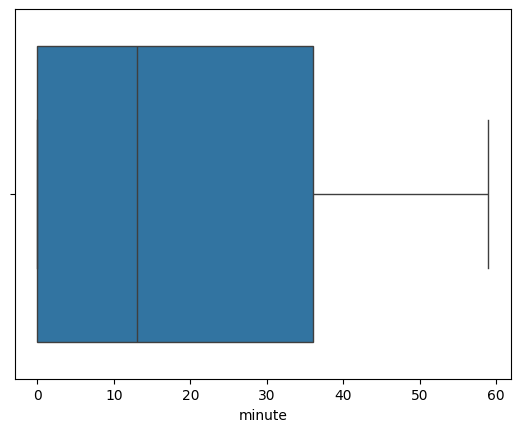

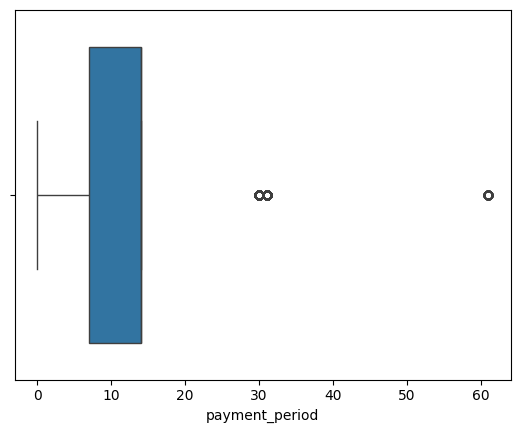

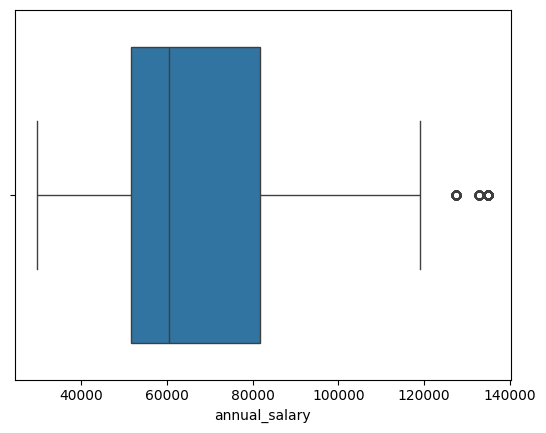

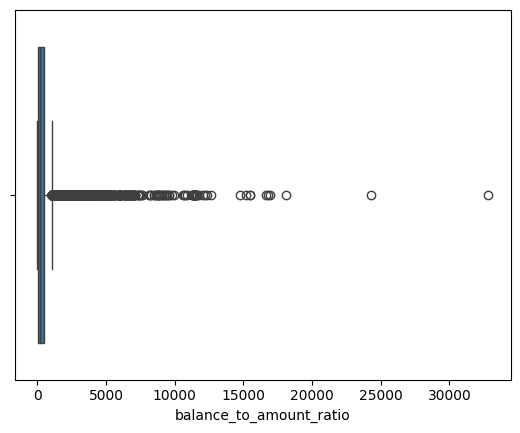

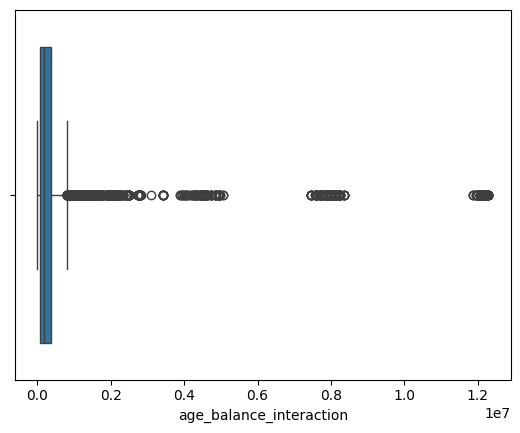

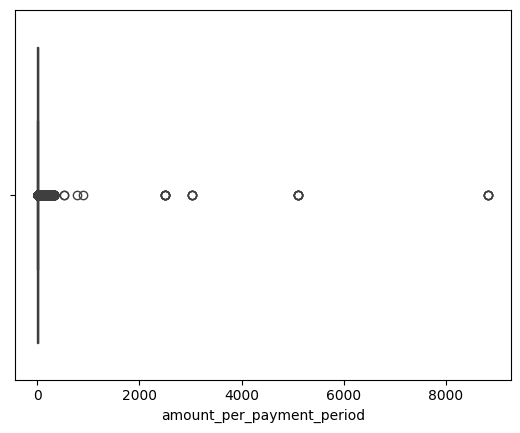

In [27]:
for i in dt_knn.columns:
  if dt_knn[i].dtype != object and i not in ['is_salary_transaction','is_weekend_spender', 'is_debit', 'is_business_hours','is_card_present','is_authorized_only','year','merchant_code']:
    sns.boxplot(data=dt_knn, x=dt_knn[i])
    plt.show()

In [28]:
q1 = dt_knn.quantile(0.25, numeric_only=True)
q3 = dt_knn.quantile(0.75, numeric_only=True)

iqr= q3-q1
upper = q3 + 1.5*iqr
lower = q1 - 1.5*iqr

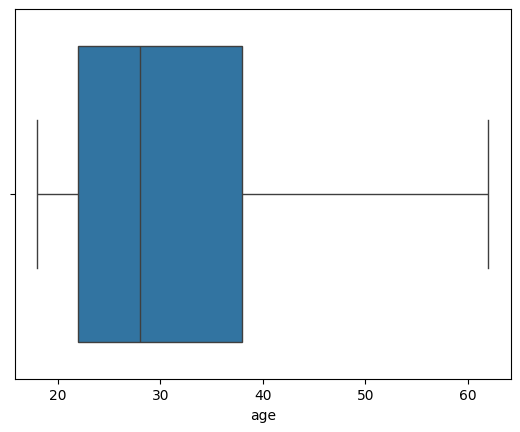

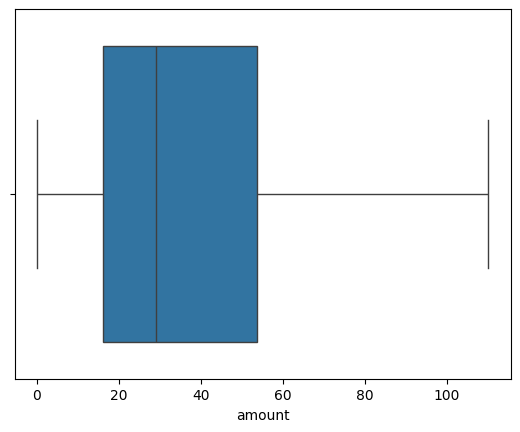

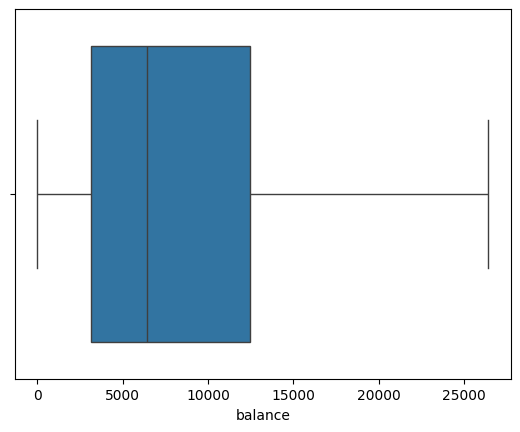

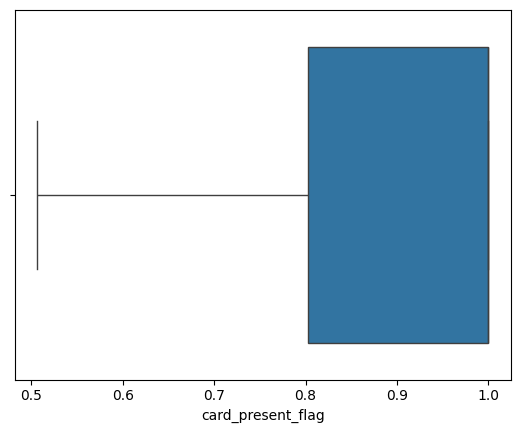

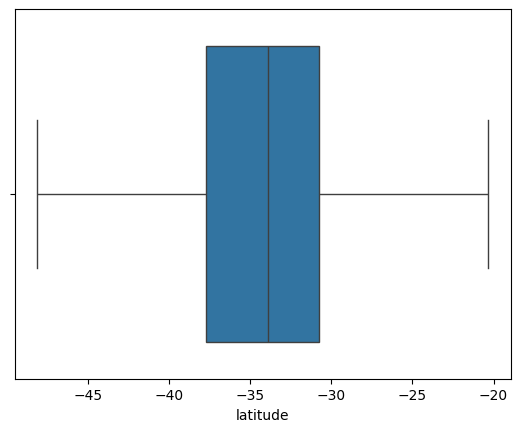

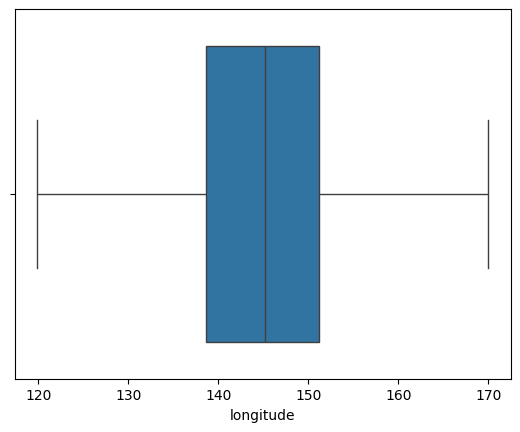

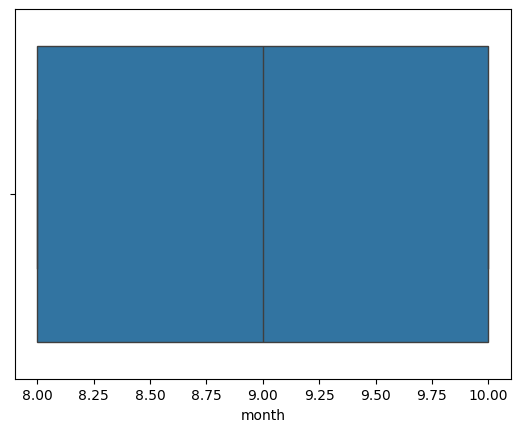

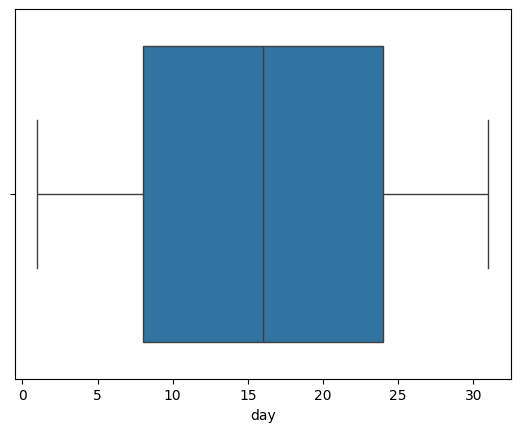

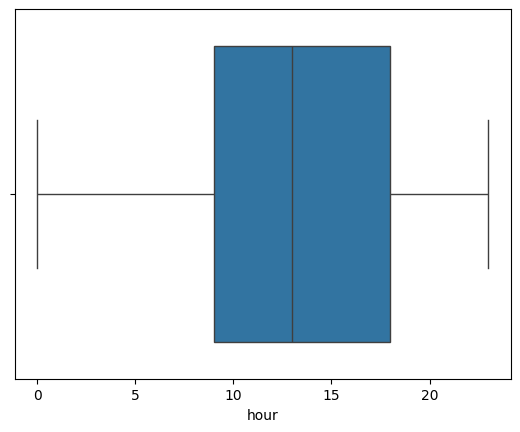

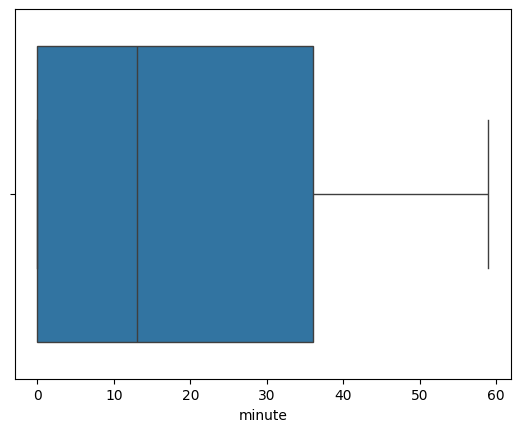

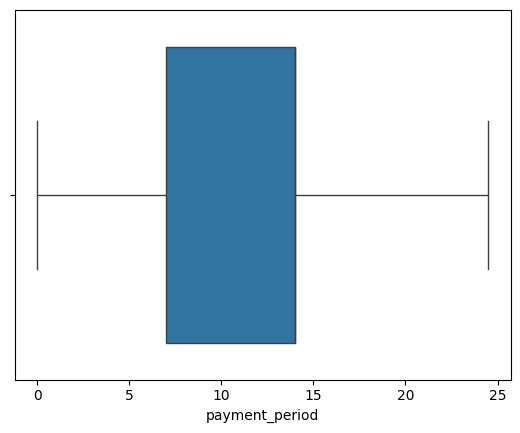

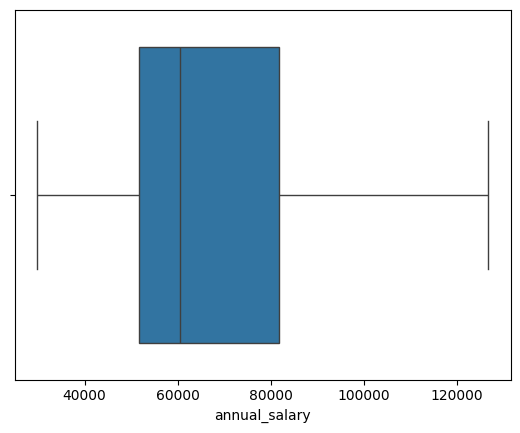

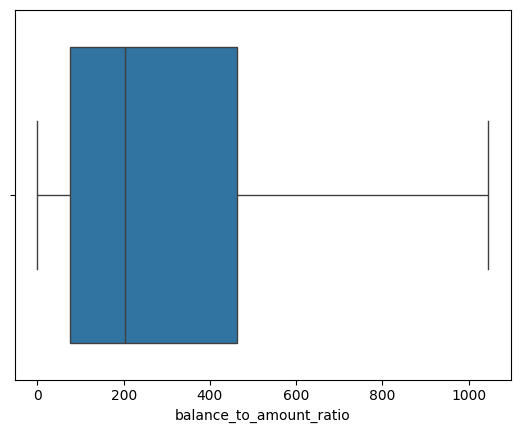

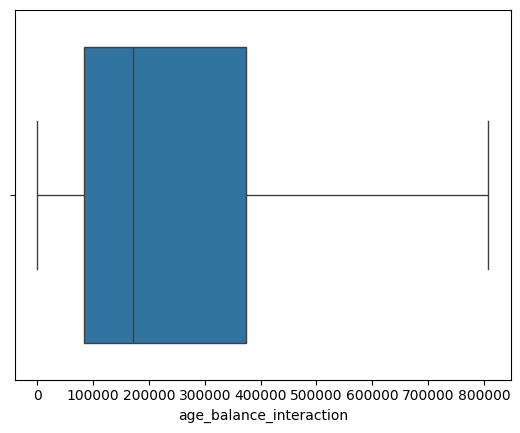

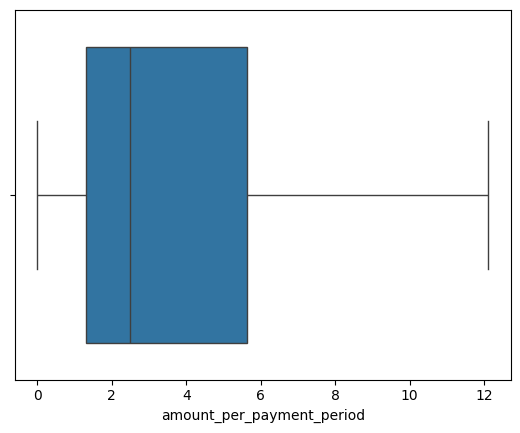

In [29]:
for i in dt_knn.columns:
  if dt_knn[i].dtypes != object and i not in ['is_salary_transaction','is_weekend_spender', 'is_debit', 'is_business_hours','is_card_present','is_authorized_only','year','merchant_code']:
    dt_knn[i] = np.where(dt_knn[i]> upper[i], upper[i], dt_knn[i])
    dt_knn[i] = np.where(dt_knn[i]< lower[i], lower[i], dt_knn[i])
    sns.boxplot(data=dt_knn,x=dt_knn[i])
    plt.show()

### Normality Test

In [30]:
for i in dt_knn.columns:
  if dt_knn[i].dtype in ['int64', 'float64']:

    kstest_statistic, kstest_p_value = stats.kstest(dt_knn[i], 'norm')
    print(f'Column: {i}')
    print(f'p-value: {kstest_p_value}')

    if kstest_p_value > 0.05:
      print('Data looks normally distributed')
      print()

    else:
      print('Data does not look normally distributed')
      print()

Column: age
p-value: 0.0
Data does not look normally distributed

Column: amount
p-value: 0.0
Data does not look normally distributed

Column: balance
p-value: 0.0
Data does not look normally distributed

Column: card_present_flag
p-value: 0.0
Data does not look normally distributed

Column: latitude
p-value: 0.0
Data does not look normally distributed

Column: longitude
p-value: 0.0
Data does not look normally distributed

Column: merchant_code
p-value: 0.0
Data does not look normally distributed

Column: year
p-value: 0.0
Data does not look normally distributed

Column: month
p-value: 0.0
Data does not look normally distributed

Column: day
p-value: 0.0
Data does not look normally distributed

Column: hour
p-value: 0.0
Data does not look normally distributed

Column: minute
p-value: 0.0
Data does not look normally distributed

Column: payment_period
p-value: 0.0
Data does not look normally distributed

Column: annual_salary
p-value: 0.0
Data does not look normally distributed

Column

### Feature Selection

In [31]:
def targetcorr(data,target,threshold=0.1):
  corr_matrix = data.corr(method='spearman', numeric_only=True)
  target_corr = corr_matrix[target].abs() > threshold
  variable_explaining_target = target_corr[target_corr].index.tolist()

  variable_explaining_target.remove(target)

  result_explaining_target = pd.DataFrame(
    {'Variable': variable_explaining_target,
    'Correlation with Target': corr_matrix.loc[variable_explaining_target, target]})

  result_explaining_target.reset_index(drop=True, inplace=True)

  return result_explaining_target

target_result = targetcorr(dt_knn, 'annual_salary')
target_result

,Variable,Correlation with Target
0,amount,0.108881
1,balance,0.485590
2,longitude,-0.118930
3,minute,-0.110548
4,payment_period,0.133756
5,balance_to_amount_ratio,0.297027
6,age_balance_interaction,0.455500
7,is_card_present,-0.112771
8,is_authorized_only,-0.134139


In [32]:
def intercorr(data,target,threshold=0.7):

  corr = data.corr(method='spearman',numeric_only=True)
  mask = np.triu(np.ones(corr.shape),k=1).astype(bool)
  high_corr = corr.where(mask).stack().reset_index()

  high_corr.columns = ['Variable1','Variable2','Correlation']
  high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]

  return high_corr.reset_index(drop=True)

intercorr_result = intercorr(dt_knn,'annual_salary')
intercorr_result

,Variable1,Variable2,Correlation
0,amount,amount_per_payment_period,0.882721
1,balance,age_balance_interaction,0.957591
2,card_present_flag,is_card_present,0.958563
3,minute,is_authorized_only,0.841495
4,is_salary_transaction,is_debit,-1.000000
5,is_card_present,is_authorized_only,0.770484


In [34]:
def vif (data, variables):
  vif_data = data[variables]
  vif_score = [variance_inflation_factor(vif_data.values,i) for i in range(vif_data.shape[1])]
  vif_result = pd.DataFrame({'Feature': variables,'VIF': vif_score})
  return vif_result

In [35]:
target_result.Variable.tolist()

['amount',
 'balance',
 'longitude',
 'minute',
 'payment_period',
 'balance_to_amount_ratio',
 'age_balance_interaction',
 'is_card_present',
 'is_authorized_only']

In [39]:
vif_results = vif(dt_knn,['amount',
 #'balance',
 #'longitude',
 'minute',
 'payment_period',
 'balance_to_amount_ratio',
 #'age_balance_interaction',
 'is_card_present',
 #'is_authorized_only'
                          ])
vif_results

,Feature,VIF
0,amount,2.107030
1,minute,2.692405
2,payment_period,4.282801
3,balance_to_amount_ratio,2.109202
4,is_card_present,2.835375


In [40]:
dt_knn.drop(dt_knn[['age','balance','card_present_flag','latitude','longitude','merchant_code','year','day','hour','month','amount_per_payment_period','is_salary_transaction','is_weekend_spender','is_debit','is_business_hours','is_authorized_only','age_balance_interaction']],axis=1,inplace=True)

### Encoding & Scaling

In [44]:
for i in dt_knn.columns:
  if dt_knn[i].dtypes not in ['float64','int64']:
    print(dt_knn[i].value_counts())

gender
M    6285
F    5758
Name: count, dtype: int64
merchant_state
NSW    6495
VIC    2131
QLD    1556
WA     1100
SA      415
NT      205
ACT      73
TAS      68
Name: count, dtype: int64
movement
debit     11160
credit      883
Name: count, dtype: int64
status
authorized    7717
posted        4326
Name: count, dtype: int64
txn_description
SALES-POS     3934
POS           3783
PAYMENT       2600
PAY/SALARY     883
INTER BANK     742
PHONE BANK     101
Name: count, dtype: int64
bin_age
20-30    5071
30-40    3405
<20      1900
40-50    1293
60-70     190
50-60     150
70>        34
Name: count, dtype: int64
dow
Friday       2073
Wednesday    2063
Thursday     1801
Saturday     1709
Sunday       1550
Tuesday      1487
Monday       1360
Name: count, dtype: int64


In [45]:
dt_knn['gender'] = dt_knn['gender'].map({'F':0, 'M':1})
dt_knn['movement'] = dt_knn['movement'].map({'credit':0, 'debit':1})
dt_knn['status'] = dt_knn['status'].map({'authorized':0, 'posted':1})
dt_knn['txn_description'] = dt_knn['txn_description'].map({'PAY/SALARY':0, 'POS':1,'SALES-POS':2,'PAYMENT':3,'INTER BANK':4,'PHONE BANK':5})

In [46]:
bin_age_map = {
    '<20': 1,
    '20-30': 2,
    '30-40': 3,
    '40-50': 4,
    '50-60': 5,
    '60-70': 6,
    '70>': 7
}

dt_knn['bin_age'] = dt_knn['bin_age'].map(bin_age_map)

In [47]:
dt_knn= pd.get_dummies(dt_knn, drop_first=True, dtype=int)

## Train / Test Split

In [49]:
target = dt['annual_salary']
inputs_knn = dt_knn.drop(dt_knn[['annual_salary']],axis=1)
inputs_rf = dt_rf.drop(dt_rf[['annual_salary']],axis=1)

In [50]:
scaler=StandardScaler()
scaler.fit(inputs_knn)
scaled_inns = scaler.transform(inputs_knn)
data_scaled = pd.DataFrame(scaled_inns, columns=inputs_knn.columns)

data_scaled

,amount,gender,movement,status,txn_description,bin_age,minute,payment_period,balance_to_amount_ratio,is_card_present,merchant_state_NSW,merchant_state_NT,merchant_state_QLD,merchant_state_SA,merchant_state_TAS,merchant_state_VIC,merchant_state_WA,dow_Monday,dow_Saturday,dow_Sunday,dow_Thursday,dow_Tuesday,dow_Wednesday
0,-0.735564,-1.044761,0.281286,-0.748719,-0.847735,-0.433405,-0.905995,-0.803178,-0.976903,0.971751,-1.081985,-0.131595,2.596097,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
1,-0.795004,-1.044761,0.281286,-0.748719,0.090531,-0.433405,-0.302321,-0.803178,-0.978878,-1.029070,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
2,-1.110673,-1.044761,0.281286,-0.748719,0.090531,-0.433405,1.609312,-0.803178,-0.970361,0.971751,-1.081985,-0.131595,2.596097,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
3,-0.797601,-1.044761,0.281286,-0.748719,-0.847735,-0.433405,-0.503546,-0.803178,-0.982314,0.971751,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
4,-0.896572,-1.044761,0.281286,-0.748719,-0.847735,-0.433405,-0.000485,-0.803178,-0.723232,0.971751,-1.081985,-0.131595,2.596097,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12038,1.973517,-1.044761,-3.555099,1.335614,-1.786002,-0.433405,-0.956301,2.757141,-0.975208,-1.029070,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
12039,1.973517,-1.044761,-3.555099,1.335614,-1.786002,-0.433405,-0.956301,2.757141,-0.980070,-1.029070,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458
12040,1.973517,-1.044761,-3.555099,1.335614,-1.786002,-0.433405,-0.956301,2.757141,-0.977568,-1.029070,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,-0.454657
12041,1.973517,0.957157,-3.555099,1.335614,-1.786002,-0.433405,-0.956301,2.757141,-0.980068,-1.029070,0.924227,-0.131595,-0.385194,-0.188917,-0.075356,-0.463672,-0.31705,-0.356798,-0.406665,-0.38434,-0.419338,-0.375324,2.199458


In [51]:
x_train_rf,x_test_rf,y_train_rf,y_test_rf = train_test_split(inputs_rf,target, test_size=0.2, random_state=42)
x_train_knn, x_test_knn, y_train_knn, y_test_knn = train_test_split(data_scaled, target, test_size = 0.2, random_state = 42)

## Model Evaluation Function

In [52]:
def evaluate(model,x_train,y_train,x_test,y_test):
  y_pred_train = model.predict(x_train)

  mae_train = metrics.mean_absolute_error(y_train,y_pred_train)
  mse_train = metrics.mean_squared_error(y_train,y_pred_train)
  rmse_train = np.sqrt(mse_train)
  r2_train = metrics.r2_score(y_train, y_pred_train)

  y_pred_test = model.predict(x_test)

  mae_test = metrics.mean_absolute_error(y_test,y_pred_test)
  mse_test = metrics.mean_squared_error(y_test,y_pred_test)
  rmse_test = np.sqrt(mse_test)
  r2_test = metrics.r2_score(y_test, y_pred_test)

  results_dict = {
        'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
        'Train': [mae_train, mse_train, rmse_train, r2_train*100],
        'Test': [mae_test, mse_test, rmse_test, r2_test*100]
    }

  results_df = pd.DataFrame(results_dict)

  return results_df

## Baseline Models

In [53]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_rf,y_train_rf)

RandomForestRegressor(random_state=42)

In [55]:
evaluate_score_rf = evaluate(rf,x_train_rf,y_train_rf,x_test_rf,y_test_rf)
evaluate_score_rf

,Metric,Train,Test
0,MAE,220.8282,515.2768
1,MSE,707848.3589,3422011.5862
2,RMSE,841.3372,1849.8680
3,R2,99.8803,99.4174


In [56]:
knn = KNeighborsRegressor()
knn.fit(x_train_knn, y_train_knn)

KNeighborsRegressor()

In [57]:
evaluate_score_knn = evaluate(knn,x_train_knn,y_train_knn,x_test_knn,y_test_knn)
evaluate_score_knn

,Metric,Train,Test
0,MAE,7893.4318,10285.4292
1,MSE,187388271.9975,302649484.5951
2,RMSE,13688.9836,17396.8240
3,R2,68.3038,48.4720


## Hyperparameter Optimization

In [58]:
!pip install optuna
from sklearn.model_selection import cross_val_score
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.2 MB/s eta 0:00:00


In [79]:
def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
    'leaf_size': trial.suggest_int('leaf_size', 10, 50),
    'p': trial.suggest_int('p', 1, 2),
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
}

    knn_clf = KNeighborsRegressor(**param)

    roc = cross_val_score(knn_clf, x_train_knn, y_train_knn, cv=5, scoring='r2', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=15)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsRegressor(**best_params)

[I 2026-04-20 10:35:39,750] A new study created in memory with name: no-name-e3a96bad-6a13-4478-b5d7-aa7a5593af25
[I 2026-04-20 10:35:46,344] Trial 0 finished with value: 0.48036321994611997 and parameters: {'n_neighbors': 47, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 29, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.48036321994611997.
[I 2026-04-20 10:35:49,350] Trial 1 finished with value: 0.49355071084885693 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 18, 'p': 2, 'metric': 'euclidean'}. Best is trial 1 with value: 0.49355071084885693.
[I 2026-04-20 10:35:49,771] Trial 2 finished with value: 0.5003824062063429 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 38, 'p': 2, 'metric': 'minkowski'}. Best is trial 2 with value: 0.5003824062063429.
[I 2026-04-20 10:35:50,182] Trial 3 finished with value: 0.4721972402128512 and parameters: {'n_neighbors': 3, 'wei

Best trial:
  Value: 0.523
  Params:  {'n_neighbors': 17, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 38, 'p': 1, 'metric': 'manhattan'}


In [80]:
best_knn_model.fit(x_train_knn, y_train_knn)

KNeighborsRegressor(algorithm='ball_tree', leaf_size=38, metric='manhattan',
                    n_neighbors=17, p=1, weights='distance')

In [81]:
best_knn_result = evaluate(best_knn_model,x_train_knn, y_train_knn,x_test_knn, y_test_knn)
best_knn_result

,Metric,Train,Test
0,MAE,0.0000,10105.4457
1,MSE,0.0000,265532728.2436
2,RMSE,0.0000,16295.1750
3,R2,100.0000,54.7913


In [82]:
def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
    'max_features': trial.suggest_float('max_features', 0.3, 0.5),
    'max_depth': trial.suggest_int('max_depth', 10,100),
    'min_samples_split': trial.suggest_int('min_samples_split', 2,40),
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1,20),
    }

    rf_opt = RandomForestRegressor(**param)

    roc = cross_val_score(rf_opt, x_train_rf,y_train_rf, cv=5, scoring='r2', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=30)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestRegressor(**best_params)

[I 2026-04-20 10:36:52,305] A new study created in memory with name: no-name-b1e3e154-7710-4697-a799-15137efc3e09
[I 2026-04-20 10:37:04,622] Trial 0 finished with value: 0.9322560941935134 and parameters: {'n_estimators': 131, 'max_features': 0.41602196550969034, 'max_depth': 46, 'min_samples_split': 14, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.9322560941935134.
[I 2026-04-20 10:37:11,586] Trial 1 finished with value: 0.8896309588737088 and parameters: {'n_estimators': 107, 'max_features': 0.4066693057268751, 'max_depth': 29, 'min_samples_split': 36, 'min_samples_leaf': 17}. Best is trial 0 with value: 0.9322560941935134.
[I 2026-04-20 10:37:29,752] Trial 2 finished with value: 0.9630444113135562 and parameters: {'n_estimators': 181, 'max_features': 0.41175092263070995, 'max_depth': 85, 'min_samples_split': 19, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.9630444113135562.
[I 2026-04-20 10:37:58,679] Trial 3 finished with value: 0.9058361757896091 and parameters

Best trial:
  Value: 0.983
  Params:  {'n_estimators': 156, 'max_features': 0.45503307824038886, 'max_depth': 66, 'min_samples_split': 7, 'min_samples_leaf': 1}


In [83]:
brfm = best_rf_model.fit(x_train_rf,y_train_rf)

In [84]:
best_rf_result = evaluate(brfm,x_train_rf,y_train_rf, x_test_rf,y_test_rf)
best_rf_result

,Metric,Train,Test
0,MAE,433.0296,841.8235
1,MSE,1490655.7119,4739399.3293
2,RMSE,1220.9241,2177.0162
3,R2,99.7479,99.1931


## Importance of variables

In [63]:
def plot_feature_importances(model,feature_names):
  importances = model.feature_importances_

  importance_df = pd.DataFrame({
      'Feature': feature_names,
      'Importance': importances
  }).sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10,6))
  plt.barh(importance_df['Feature'], importance_df['Importance'])
  plt.title("Feature Importances")
  plt.xlabel("Importance Score")
  plt.ylabel("Feature")
  plt.gca().invert_yaxis()
  plt.show()

  return importance_df

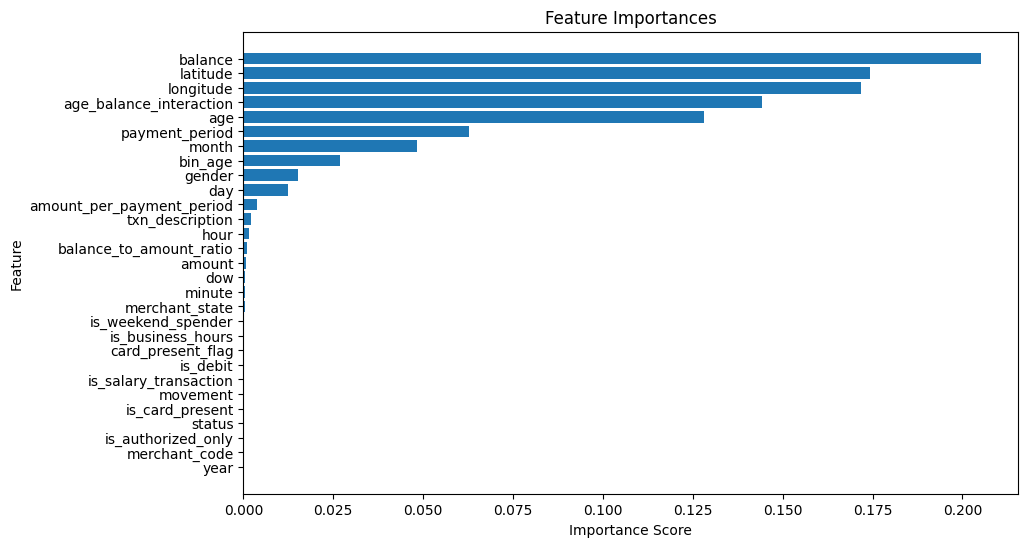

,Feature,Importance
2,balance,0.2053
5,latitude,0.1743
6,longitude,0.1719
25,age_balance_interaction,0.1441
0,age,0.1282
19,payment_period,0.0626
14,month,0.0482
12,bin_age,0.0267
4,gender,0.0152
15,day,0.0125


In [64]:
feature_names = inputs_rf.columns
feature_importance_df = plot_feature_importances(rf, feature_names)

feature_importance_df

In [86]:
imp = feature_importance_df[feature_importance_df['Importance']>0.01]

imp

,Feature,Importance
2,balance,0.2053
5,latitude,0.1743
6,longitude,0.1719
25,age_balance_interaction,0.1441
0,age,0.1282
19,payment_period,0.0626
14,month,0.0482
12,bin_age,0.0267
4,gender,0.0152
15,day,0.0125


In [87]:
new_inputs_rf = imp['Feature'].tolist()

new_inputs_rf

['balance',
 'latitude',
 'longitude',
 'age_balance_interaction',
 'age',
 'payment_period',
 'month',
 'bin_age',
 'gender',
 'day']

In [88]:
fin_input_rf = dt_rf[imp['Feature'].tolist()]
fin_output = dt['annual_salary']
x_train_fin_rf, x_test_fin_rf, y_train_fin_rf, y_test_fin_rf = train_test_split(fin_input_rf, fin_output, test_size=0.2, random_state=42)

In [89]:
brfm_imp = best_rf_model.fit(x_train_fin_rf,y_train_fin_rf)

In [91]:
best_rf_imp_result = evaluate(brfm_imp,x_train_fin_rf,y_train_fin_rf, x_test_fin_rf,y_test_fin_rf)
best_rf_imp_result

,Metric,Train,Test
0,MAE,211.3402,391.1689
1,MSE,523549.1281,1872514.1644
2,RMSE,723.5669,1368.3984
3,R2,99.9114,99.6812


## Model Comparison

In [93]:
def get_r2(result_df):
    train_r2 = result_df[result_df['Metric'] == 'R2']['Train'].values[0]
    test_r2  = result_df[result_df['Metric'] == 'R2']['Test'].values[0]
    return train_r2, test_r2

result_df = pd.DataFrame({
    'Models': ['KNN', 'RandomForest', 'RF Optuna Important Features', 'KNN Optuna', 'RandomForest Optuna'],
    'Train R2': [get_r2(evaluate_score_knn)[0],
                 get_r2(evaluate_score_rf)[0],
                 get_r2(best_rf_imp_result)[0],
                 get_r2(best_knn_result)[0],
                 get_r2(best_rf_result)[0]],
    'Test R2':  [get_r2(evaluate_score_knn)[1],
                 get_r2(evaluate_score_rf)[1],
                 get_r2(best_rf_imp_result)[1],
                 get_r2(best_knn_result)[1],
                 get_r2(best_rf_result)[1]],
})

print(result_df)

                         Models  Train R2  Test R2
0                           KNN   68.3038  48.4720
1                  RandomForest   99.8803  99.4174
2  RF Optuna Important Features   99.9114  99.6812
3                    KNN Optuna  100.0000  54.7913
4           RandomForest Optuna   99.7479  99.1931


## Winner: RF Optuna ( with importante features)

In [95]:
dep = pd.read_excel(r'/content/income_deploy.xlsx')
dep

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,longitude,merchant_code,merchant_id,merchant_state,merchant_suburb,movement,status,transaction_id,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period
0,ACC-4258502723,24,116.2600,4241.7600,1.0000,CUS-3378712515,2018-10-08,Kimberly,F,-37.7400,145.4500,NaN,e7bf57d9-9eeb-41b4-886e-efb676a5bd80,QLD,Port Douglas,debit,authorized,b1e504ecf44840abb3a48b4ab8510f00,SALES-POS,20-30,2018,10,8,13,33,Monday,7
1,ACC-4258502723,24,14.1800,5122.4900,1.0000,CUS-3378712515,2018-10-11,Kimberly,F,-37.7400,145.4500,NaN,7770e116-8b4a-4d48-b0f5-7a6399958848,VIC,Melton,debit,authorized,dfa272cc57334c7ca87f61a258cb5b90,SALES-POS,20-30,2018,10,11,12,7,Thursday,7
2,ACC-1279356312,44,17.4000,5906.2800,1.0000,CUS-1892177589,2018-08-29,Tyler,M,-37.7300,144.7900,NaN,8bee9f57-4517-4f80-b7ee-c161f33421e2,VIC,Preston,debit,authorized,d87dc36be2a2414784dd1c84ced28c71,POS,40-50,2018,8,29,9,43,Wednesday,14
3,ACC-1344825761,46,22.0000,15729.7300,NaN,CUS-1499065773,2018-08-17,Sarah,F,-33.9100,151.0900,NaN,NaN,NaN,NaN,debit,posted,4d250222351c4fdb90f7a3085f881276,PAYMENT,40-50,2018,8,17,14,0,Friday,14
4,ACC-2171593283,19,33.0000,11168.8100,NaN,CUS-2317998716,2018-09-06,Fernando,M,-36.0400,146.9400,NaN,NaN,NaN,NaN,debit,posted,a4154a29a5d642ca9643b402a87e39d3,PAYMENT,<20,2018,9,6,5,0,Thursday,14
5,ACC-240804743,29,56.0000,7651.4600,NaN,CUS-261674136,2018-08-29,Kenneth,M,-30.7500,121.4800,NaN,NaN,NaN,NaN,debit,posted,010cfffccf6c4fefb0a7d0b88a6d68da,PAYMENT,20-30,2018,8,29,14,0,Wednesday,14
6,ACC-3954677887,47,24.0000,1161.9100,NaN,CUS-3716701010,2018-08-11,Ruth,F,-32.2800,115.7200,NaN,NaN,NaN,NaN,debit,posted,ec40f0d4f9be46f18d93bf86971f38dc,PAYMENT,40-50,2018,8,11,23,0,Saturday,7
7,ACC-2920611728,69,39.1200,5215.7700,1.0000,CUS-1388323263,2018-09-12,Tyler,M,-37.7600,144.9600,NaN,9cf12ed7-1600-403d-bb24-7f61d51609ef,VIC,Hoppers Crossing,debit,authorized,9c4b758fc15c4aaca329872b206da045,SALES-POS,60-70,2018,9,12,1,12,Wednesday,7
8,ACC-2305712452,18,18.0400,2390.8800,1.0000,CUS-1842679196,2018-08-31,Debra,F,-34.8900,138.6100,NaN,ae05bf40-b7dc-41a1-8ac1-61c0e8608760,SA,Gilles Plains,debit,authorized,03a5e32154914752a4316fa6663633b6,SALES-POS,<20,2018,8,31,21,19,Friday,7
9,ACC-1710017148,19,16.1800,1609.1600,1.0000,CUS-883482547,2018-08-01,Michelle,F,-34.0100,150.8200,NaN,499b1c74-d767-43d6-a084-b20d00010c70,NSW,Blacktown,debit,authorized,927d07bdbeb743ebab2865f86132cd99,POS,<20,2018,8,1,14,37,Wednesday,14


In [102]:
data_dep = dep.copy()

In [103]:
data_dep['age_balance_interaction'] = data_dep['age'] * data_dep['balance']

In [104]:
data_dep.columns

Index(['account', 'age', 'amount', 'balance', 'card_present_flag',
       'customer_id', 'date', 'first_name', 'gender', 'latitude', 'longitude',
       'merchant_code', 'merchant_id', 'merchant_state', 'merchant_suburb',
       'movement', 'status', 'transaction_id', 'txn_description', 'bin_age',
       'year', 'month', 'day', 'hour', 'minute', 'dow', 'payment_period',
       'age_balance_interaction'],
      dtype='object')

In [105]:
data_dep.drop(data_dep[[
    'account',
    'amount',
    'card_present_flag',
    'customer_id',
    'date',
    'first_name',
    'merchant_code',
    'merchant_id',
    'merchant_state',
    'merchant_suburb',
    'movement',
    'status',
    'transaction_id',
    'txn_description',
    'year',
    'hour',
    'minute',
    'dow'
]], axis=1, inplace=True)

In [106]:
data_dep.columns

Index(['age', 'balance', 'gender', 'latitude', 'longitude', 'bin_age', 'month',
       'day', 'payment_period', 'age_balance_interaction'],
      dtype='object')

In [110]:
bin_age_map = {
    '<20': 1,
    '20-30': 2,
    '30-40': 3,
    '40-50': 4,
    '50-60': 5,
    '60-70': 6,
    '70>': 7
}

data_dep['bin_age'] = data_dep['bin_age'].map(bin_age_map)

In [111]:
data_dep['gender'] = data_dep['gender'].map({'F':0, 'M':1})

In [116]:
data_dep = data_dep.reindex(columns=fin_input_rf.columns)

In [117]:
data_dep['prediction'] = brfm_imp.predict(data_dep)
data_dep

,balance,latitude,longitude,age_balance_interaction,age,payment_period,month,bin_age,gender,day,prediction
0,4241.7600,-37.7400,145.4500,101802.2400,24,7,10,2,0,8,54918.4882
1,5122.4900,-37.7400,145.4500,122939.7600,24,7,10,2,0,11,55130.7940
2,5906.2800,-37.7300,144.7900,259876.3200,44,14,8,4,1,29,73780.9576
3,15729.7300,-33.9100,151.0900,723567.5800,46,14,8,4,0,17,67875.4103
4,11168.8100,-36.0400,146.9400,212207.3900,19,14,9,1,1,6,69552.3787
5,7651.4600,-30.7500,121.4800,221892.3400,29,14,8,2,1,29,110108.9307
6,1161.9100,-32.2800,115.7200,54609.7700,47,7,8,4,0,11,67695.1669
7,5215.7700,-37.7600,144.9600,359888.1300,69,7,9,6,1,12,53977.4919
8,2390.8800,-34.8900,138.6100,43035.8400,18,7,8,1,0,31,41138.2269
9,1609.1600,-34.0100,150.8200,30574.0400,19,14,8,1,0,1,98382.0094


In [118]:
dep['Predictions'] = data_dep['prediction']


In [119]:
dep

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,longitude,merchant_code,merchant_id,merchant_state,merchant_suburb,movement,status,transaction_id,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period,Predictions
0,ACC-4258502723,24,116.2600,4241.7600,1.0000,CUS-3378712515,2018-10-08,Kimberly,F,-37.7400,145.4500,NaN,e7bf57d9-9eeb-41b4-886e-efb676a5bd80,QLD,Port Douglas,debit,authorized,b1e504ecf44840abb3a48b4ab8510f00,SALES-POS,20-30,2018,10,8,13,33,Monday,7,54918.4882
1,ACC-4258502723,24,14.1800,5122.4900,1.0000,CUS-3378712515,2018-10-11,Kimberly,F,-37.7400,145.4500,NaN,7770e116-8b4a-4d48-b0f5-7a6399958848,VIC,Melton,debit,authorized,dfa272cc57334c7ca87f61a258cb5b90,SALES-POS,20-30,2018,10,11,12,7,Thursday,7,55130.7940
2,ACC-1279356312,44,17.4000,5906.2800,1.0000,CUS-1892177589,2018-08-29,Tyler,M,-37.7300,144.7900,NaN,8bee9f57-4517-4f80-b7ee-c161f33421e2,VIC,Preston,debit,authorized,d87dc36be2a2414784dd1c84ced28c71,POS,40-50,2018,8,29,9,43,Wednesday,14,73780.9576
3,ACC-1344825761,46,22.0000,15729.7300,NaN,CUS-1499065773,2018-08-17,Sarah,F,-33.9100,151.0900,NaN,NaN,NaN,NaN,debit,posted,4d250222351c4fdb90f7a3085f881276,PAYMENT,40-50,2018,8,17,14,0,Friday,14,67875.4103
4,ACC-2171593283,19,33.0000,11168.8100,NaN,CUS-2317998716,2018-09-06,Fernando,M,-36.0400,146.9400,NaN,NaN,NaN,NaN,debit,posted,a4154a29a5d642ca9643b402a87e39d3,PAYMENT,<20,2018,9,6,5,0,Thursday,14,69552.3787
5,ACC-240804743,29,56.0000,7651.4600,NaN,CUS-261674136,2018-08-29,Kenneth,M,-30.7500,121.4800,NaN,NaN,NaN,NaN,debit,posted,010cfffccf6c4fefb0a7d0b88a6d68da,PAYMENT,20-30,2018,8,29,14,0,Wednesday,14,110108.9307
6,ACC-3954677887,47,24.0000,1161.9100,NaN,CUS-3716701010,2018-08-11,Ruth,F,-32.2800,115.7200,NaN,NaN,NaN,NaN,debit,posted,ec40f0d4f9be46f18d93bf86971f38dc,PAYMENT,40-50,2018,8,11,23,0,Saturday,7,67695.1669
7,ACC-2920611728,69,39.1200,5215.7700,1.0000,CUS-1388323263,2018-09-12,Tyler,M,-37.7600,144.9600,NaN,9cf12ed7-1600-403d-bb24-7f61d51609ef,VIC,Hoppers Crossing,debit,authorized,9c4b758fc15c4aaca329872b206da045,SALES-POS,60-70,2018,9,12,1,12,Wednesday,7,53977.4919
8,ACC-2305712452,18,18.0400,2390.8800,1.0000,CUS-1842679196,2018-08-31,Debra,F,-34.8900,138.6100,NaN,ae05bf40-b7dc-41a1-8ac1-61c0e8608760,SA,Gilles Plains,debit,authorized,03a5e32154914752a4316fa6663633b6,SALES-POS,<20,2018,8,31,21,19,Friday,7,41138.2269
9,ACC-1710017148,19,16.1800,1609.1600,1.0000,CUS-883482547,2018-08-01,Michelle,F,-34.0100,150.8200,NaN,499b1c74-d767-43d6-a084-b20d00010c70,NSW,Blacktown,debit,authorized,927d07bdbeb743ebab2865f86132cd99,POS,<20,2018,8,1,14,37,Wednesday,14,98382.0094
